# **WISDM - Resnet (PyTorch)**

In [35]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

In [36]:
# 디바이스 설정 (GPU 사용 가능 여부 확인)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Data load

In [37]:
DATASET_PATH = "/content/drive/MyDrive/AI_Study/WISDM_Dataset/WISDM_ar_v1.1_raw.txt"

# Seed 고정

In [38]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# 데이터 전처리

컬럼명 지정 (WISDM raw data는 컬럼명이 없는 상태)

In [39]:
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";")            # 세미콜론 이후 내용 무시
print(data.head())

   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


결측치 제거 및 불필요한 컬럼 삭제

In [40]:
# 불필요한 'NaN' 컬럼 제거
if 'NaN' in data.columns:
    data = data.drop(columns=['NaN'])

# 결측치가 있는 행이 있다면 모두 제거
data = data.dropna().reset_index(drop=True)

문자열 데이터 -> 실수형 데이터 변환

In [41]:
# 문자열 형태로 되어 있는 x, y, z_axis 데이터를 실수형(float)으로 변환
# (WISDM 원본 데이터 중 가끔 유실되거나 문자열이 섞인 경우가 있어 타입을 강제해야 한다고 함.)
data['x_axis'] = pd.to_numeric(data['x_axis'], errors='coerce')
data['y_axis'] = pd.to_numeric(data['y_axis'], errors='coerce')
data['z_axis'] = pd.to_numeric(data['z_axis'], errors='coerce')
data = data.dropna().reset_index(drop=True)

print("\n--- 데이터 정제 후 상위 5개 행 ---")
print(data.head())


--- 데이터 정제 후 상위 5개 행 ---
   user_id activity       timestamp    x_axis     y_axis    z_axis
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164


라벨 인코딩

In [42]:
# 문자열 액티비티(Jogging, Walking 등)를 숫자로 인코딩
activity_map = {act: i for i, act in enumerate(data['activity'].unique())}
data['label'] = data['activity'].map(activity_map)
print(f"\nActivity Encoding Info: {activity_map}")


Activity Encoding Info: {'Jogging': 0, 'Walking': 1, 'Upstairs': 2, 'Downstairs': 3, 'Sitting': 4, 'Standing': 5}


정규화

In [43]:
# x, y, z 축 가속도 센서 값을 StandardScaler를 이용해 표준정규화
scaler = StandardScaler()
data[['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(data[['x_axis', 'y_axis', 'z_axis']])

Sliding Window

In [44]:
# 20Hz 데이터 기준, 보통 80개 타임스텝(4초) 윈도우와 50% 오버랩(40개씩 이동) 사용
def create_segments_and_labels(df, time_steps=80, step=40):
    segments = []
    labels = []

    x_vals = df['x_axis'].values
    y_vals = df['y_axis'].values
    z_vals = df['z_axis'].values
    label_vals = df['label'].values

    for i in range(0, len(df) - time_steps, step):
        xs = x_vals[i : i + time_steps]
        ys = y_vals[i : i + time_steps]
        zs = z_vals[i : i + time_steps]

        # 윈도우 내에서 가장 빈번하게 나온 라벨을 대표값으로 채택
        # (혹은 시작 지점의 라벨을 가져옴)
        label = label_vals[i : i + time_steps][0]

        # PyTorch 1D CNN은 [배치, 채널, 시퀀스] 구조를 받으므로 채널(3)을 앞으로 변경
        segments.append([xs, ys, zs])
        labels.append(label)

    return np.array(segments), np.array(labels)

TIME_STEPS = 80
STEP = 40
X, y = create_segments_and_labels(data, TIME_STEPS, STEP)
print(f"\n생성된 세그먼트 데이터 구조 (X): {X.shape}") # (샘플수, 3, 80)
print(f"생성된 라벨 데이터 구조 (y): {y.shape}")       # (샘플수,)


생성된 세그먼트 데이터 구조 (X): (6500, 3, 80)
생성된 라벨 데이터 구조 (y): (6500,)


Train/Test 분할

In [45]:
# Train / Test 비율을 8:2로 나눔.. 클래스 비율을 균등하게 분할하기 위해 stratify 적용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

PyTorch 텐서 형태로 변환

In [46]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model Building

Residual Block

In [47]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock1D, self).__init__()

        # 첫 번째 합성곱 레이어
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()

        # 두 번째 합성곱 레이어
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        # 지름길(Shortcut Connection) 매칭 레이어
        # 입력과 출력의 채널 수나 시퀀스 길이가 다를 때(stride > 1), 차원을 맞춰주는 역할
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        # 주 경로(Main Path) 연산
        residual = self.shortcut(x)  # Shorcut 데이터 미리 추출 및 차원 매칭

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 잔차 결합 (H(x) = F(x) + x) 및 활성화 함수 적용
        out += residual
        out = self.relu(out)
        return out

전체 1D ResNet Model

In [48]:
class WISDMResNet(nn.Module):
    def __init__(self, input_channels=3, num_classes=6):
        super(WISDMResNet, self).__init__()

        # 2-1. Stem Stage (입력 특징 추출 레이어)
        # 입력: [Batch, 3, 80] -> 출력: [Batch, 64, 80]
        self.prep_block = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

        # 2-2. Residual Stages (잔차 블록 레이어 2개)
        # Stage 1: 채널 유지, 길이 유지 -> [Batch, 64, 80]
        self.layer1 = nn.Sequential(
            ResidualBlock1D(64, 64, stride=1),
            ResidualBlock1D(64, 64, stride=1)
        )

        # Stage 2: 채널 확대 (64->128), 다운샘플링 -> [Batch, 128, 40]
        self.layer2 = nn.Sequential(
            ResidualBlock1D(64, 128, stride=2),
            ResidualBlock1D(128, 128, stride=1)
        )

        # Stage 3: 채널 확대 (128->256), 다운샘플링 -> [Batch, 256, 20]
        self.layer3 = nn.Sequential(
            ResidualBlock1D(128, 256, stride=2),
            ResidualBlock1D(256, 256, stride=1)
        )

        # 2-3. Global Average Pooling (GAP) Stage
        # 시퀀스 길이를 1로 압축하여 시간 축 변화에 강인하게 만드는 작업 -> [Batch, 256, 1]
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)

        # 2-4. Classification Stage (최종 분류기)
        # 드롭아웃을 적용하여 과적합을 방지하고 완전연결레이어를 통과시킴
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # 순전파 흐름 제어
        x = self.prep_block(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1) # Flatten: [Batch, 256]

        x = self.dropout(x)
        out = self.fc(x)
        return out

모델 생성 및 Loss+Callbacks 설정

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3-1. 깨끗하게 초기화된 ResNet 모델 인스턴스 생성
# 가중치가 1에포크 때 누적되어 시작하는 현상을 방지하기 위해 매번 완전히 새로 생성
model = WISDMResNet(input_channels=3, num_classes=6).to(device)

# 3-2. 손실함수 및 옵티마이저 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 3-3. 학습률 스케줄러 설정
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 3-4. Callbacks 및 History 수동 연동 제어 변수 초기화
best_val_acc = 0.0
patience_counter = 0
early_stopping_patience = 7
checkpoint_path = 'best_wisdm_resnet.pt'
best_model_wts = copy.deepcopy(model.state_dict()) # 초기 상태 가중치 백업

# Training & Validation

In [50]:
# --- 1. Dataset 및 DataLoader 준비 ---
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=64)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [51]:
# --- 2. History 저장을 위한 딕셔너리 정의 ---
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

In [52]:
# --- 3. 학습 및 검증 루프 실행 (epochs=150) ---
epochs = 150
print("=== WISDM 1D ResNet 모델 학습 및 Callbacks 루프 시작 ===")

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # --------------------------------------
    # [Train Phase] - 학습 단계
    # --------------------------------------
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        optimizer.step()

        # 통계 계산
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # --------------------------------------
    # [Validation Phase] - 검증 단계
    # --------------------------------------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 역전파 연산 제외로 메모리 세이브 및 가속화
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에포크 결과 출력
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --------------------------------------
    # --- 4. Callbacks 수동 연동 단계 ---
    # --------------------------------------
    # (1) ReduceLROnPlateau 스케줄러 업데이트 (검증 손실 기준 스케일링)
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"Epoch {epoch}: val_categorical_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    # 'early_stopping_patience' 정수 변수로 비교연산 진행
    if patience_counter >= early_stopping_patience:
        print(f"\n★ Early stopping triggered at Epoch {epoch}. Restoring model weights from the end of the best epoch. ★")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

=== WISDM 1D ResNet 모델 학습 및 Callbacks 루프 시작 ===
Epoch 1/150 - 2.3s - loss: 0.3937 - accuracy: 0.8565 - val_loss: 0.1783 - val_accuracy: 0.9433 - lr: 0.001000
Epoch 1: val_categorical_accuracy improved to 0.94327, saving model to best_wisdm_resnet.pt
Epoch 2/150 - 0.7s - loss: 0.1535 - accuracy: 0.9512 - val_loss: 0.1123 - val_accuracy: 0.9663 - lr: 0.001000
Epoch 2: val_categorical_accuracy improved to 0.96635, saving model to best_wisdm_resnet.pt
Epoch 3/150 - 0.7s - loss: 0.1097 - accuracy: 0.9625 - val_loss: 0.1764 - val_accuracy: 0.9375 - lr: 0.001000
Epoch 4/150 - 0.7s - loss: 0.1042 - accuracy: 0.9637 - val_loss: 0.1290 - val_accuracy: 0.9635 - lr: 0.001000
Epoch 5/150 - 0.6s - loss: 0.0687 - accuracy: 0.9791 - val_loss: 0.0881 - val_accuracy: 0.9740 - lr: 0.001000
Epoch 5: val_categorical_accuracy improved to 0.97404, saving model to best_wisdm_resnet.pt
Epoch 6/150 - 0.7s - loss: 0.0480 - accuracy: 0.9858 - val_loss: 0.0907 - val_accuracy: 0.9779 - lr: 0.001000
Epoch 6: val_cat

# Evaluation

📌 Best 기록 확인

In [60]:
# ==========================================
# 1. 가중치를 불러올 빈 모델 객체 생성 및 로드
# ==========================================
# 빈 모델 객체를 선언하고 가중치를 주입
best_model = WISDMResNet(input_channels=3, num_classes=6).to(device)

# 앞서 학습 루프에서 설정한 ResNet 저장 경로 명시 ('best_wisdm_resnet.pt')
resnet_checkpoint_path = 'best_wisdm_resnet.pt'

try:
    best_model.load_state_dict(torch.load(resnet_checkpoint_path, map_location=device))
    print(f"✅ Successfully loaded best ResNet model weights from '{resnet_checkpoint_path}'")
except FileNotFoundError:
    # 혹시 변수명이 다르게 저장되었을 경우를 대비한 예외 처리 내장
    checkpoint_path = 'best_wisdm_resnet.pt'
    best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"✅ Successfully loaded best ResNet model weights from '{checkpoint_path}'")


# ==========================================
# 2. 데이터 평가를 위한 수동 함수 정의
# ==========================================
def evaluate_pytorch_model(model, X_data, y_data, batch_size=64):
    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 평가용 DataLoader 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    # 손실 함수 정의 상태 재확인
    loss_fn = nn.CrossEntropyLoss()

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외 (메모리 절약)
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# ==========================================
# 3. Training & Test 데이터셋 평가 및 최종 출력
# ==========================================
print("\n======= 최고 기록 성능 평가 =======")

# 3-1. X_train 전체 데이터에 대해 평가
train_loss, train_acc = evaluate_pytorch_model(best_model, X_train, y_train, batch_size=64)
print(f"▶ Training Accuracy : {train_acc * 100:.2f} %")
print(f"▶ Training Loss     : {train_loss:.4f}")

print("-" * 35)

# 3-2. X_test 데이터셋에 대해 평가 (최종 일반화 성능 지표)
test_loss, test_acc = evaluate_pytorch_model(best_model, X_test, y_test, batch_size=64)
print(f"✨ Test Accuracy     : {test_acc * 100:.2f} %")
print(f"✨ Test Loss         : {test_loss:.4f}")
print("===================================")

✅ Successfully loaded best ResNet model weights from 'best_wisdm_resnet.pt'

======= 최고 기록 성능 평가 =======
▶ Training Accuracy : 99.63 %
▶ Training Loss     : 0.0212
-----------------------------------
✨ Test Accuracy     : 97.62 %
✨ Test Loss         : 0.1153


📌 Classification Report

In [65]:
import torch.nn.functional as F

# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

y_pred_list = []
with torch.no_grad():
    # [가독성 개선] batch_X[0] 대신 루프문에서 (inputs,) 형태로 바로 꺼내오면 코드가 더 깔끔해진다고 함.
    for (inputs,) in test_loader:
        inputs = inputs.to(device)

        # 순전파로 로짓(Logit) 계산
        outputs = best_model(inputs)

        # 가장 높은 값의 인덱스 추출 (소프트맥스를 안 거쳐도 대소 관계는 변하지 않으므로 argmax/max 연산이 가능)
        _, predicted = torch.max(outputs, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)

# --- 2. 분류 리포트 출력 ---
print("\n                Classification Report")
print("-" * 55)
# y_test와 y_pred를 비교하여 precision, recall, f1-score를 소수점 4자리(digits=4)까지 출력
print(classification_report(y_test, y_pred, digits=4))


                Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9916    0.9916    0.9916       476
           1     0.9920    0.9980    0.9950       496
           2     0.9407    0.8819    0.9104       144
           3     0.9054    0.9371    0.9210       143
           4     0.9583    1.0000    0.9787        23
           5     1.0000    1.0000    1.0000        18

    accuracy                         0.9762      1300
   macro avg     0.9647    0.9681    0.9661      1300
weighted avg     0.9762    0.9762    0.9760      1300



📌 지표(Metrics) 계산 및 효율성(FLOPs/추론시간) 측정
- 라이브러리 설치 : !pip install fvcore

In [67]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from fvcore.nn import FlopCountAnalysis

def evaluate_model_efficiency_and_metrics_fixed(model, test_loader, device, input_size=(1, 3, 80)):
    model.eval()

    # [1] 모델 복잡도 측정
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    dummy_input = torch.randn(*input_size).to(device)
    flops_analyzer = FlopCountAnalysis(model, dummy_input)
    flops_analyzer.unsupported_ops_warnings(False)
    total_flops = flops_analyzer.total()

    # [2] 정량 지표 및 추론 시간 측정
    all_preds = []
    all_targets = []  # 로더 내부에서 진짜 정답을 직접 수집할 리스트
    inference_times = []

    with torch.no_grad():
        for batch in test_loader:
            # 데이터 로더가 (X, y) 구조인 경우 분리
            if isinstance(batch, (list, tuple)) and len(batch) >= 2:
                inputs, batch_y = batch[0], batch[1]
            else:
                inputs = batch
                batch_y = None

            # 데이터 텐서 장치 이동
            if isinstance(inputs, torch.Tensor):
                inputs = inputs.to(device)
            else:
                inputs = torch.tensor(inputs, dtype=torch.float32).to(device)

            # 순수 추론 시간 측정
            start_time = time.time()
            outputs = model(inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.time()

            inference_times.append((end_time - start_time) * 1000 / inputs.size(0))

            # 예측값 모델 축적
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())

            # 로더 안에 매핑된 정답을 그대로 가져와 순서 불일치 완전 차단
            if batch_y is not None:
                if len(batch_y.shape) > 1 and batch_y.shape[1] > 1: # 원-핫 인코딩 대응
                    true_labels = torch.argmax(batch_y, dim=1)
                else:
                    true_labels = batch_y
                all_targets.extend(true_labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # 만약 데이터로더에 라벨이 없었던 경우에만 예외적으로 처리
    if len(all_targets) == 0:
        print("[경고] 데이터로더에 정답 라벨이 없어 연산할 수 없습니다.")
        return None, all_preds

    # 정량 지표 계산
    accuracy = accuracy_score(all_targets, all_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
    avg_inference_time = np.mean(inference_times)

    # [3] 결과 출력
    print("="*50)
    print(f"🥇 Metrics & Efficiency Evaluation")
    print("="*50)
    print(f"Accuracy     : {accuracy:.2f} %")
    print(f"F1 Score     : {f1:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Parameters   : {total_params / 1e6:.4f} M")
    print(f"FLOPs        : {total_flops / 1e6:.4f} M")
    print(f"Inference    : {avg_inference_time:.3f} ms/sample")
    print("="*50)

    return all_targets, all_preds

# --- 실행 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

targets, test_preds = evaluate_model_efficiency_and_metrics_fixed(
    model=best_model,                 # 혹은 가중치가 로드된 model 객체
    test_loader=val_loader,           # 검증용 데이터로더
    device=device,
    input_size=(1, 3, 80)
)

layer1.0.shortcut, layer1.1.shortcut, layer2.1.shortcut, layer3.1.shortcut


🥇 Metrics & Efficiency Evaluation
Accuracy     : 98.17 %
F1 Score     : 0.9632
Recall       : 0.9626
Precision    : 0.9655
Parameters   : 0.9576 M
FLOPs        : 25.8217 M
Inference    : 0.144 ms/sample


📌 Loss / Accuracy 그래프

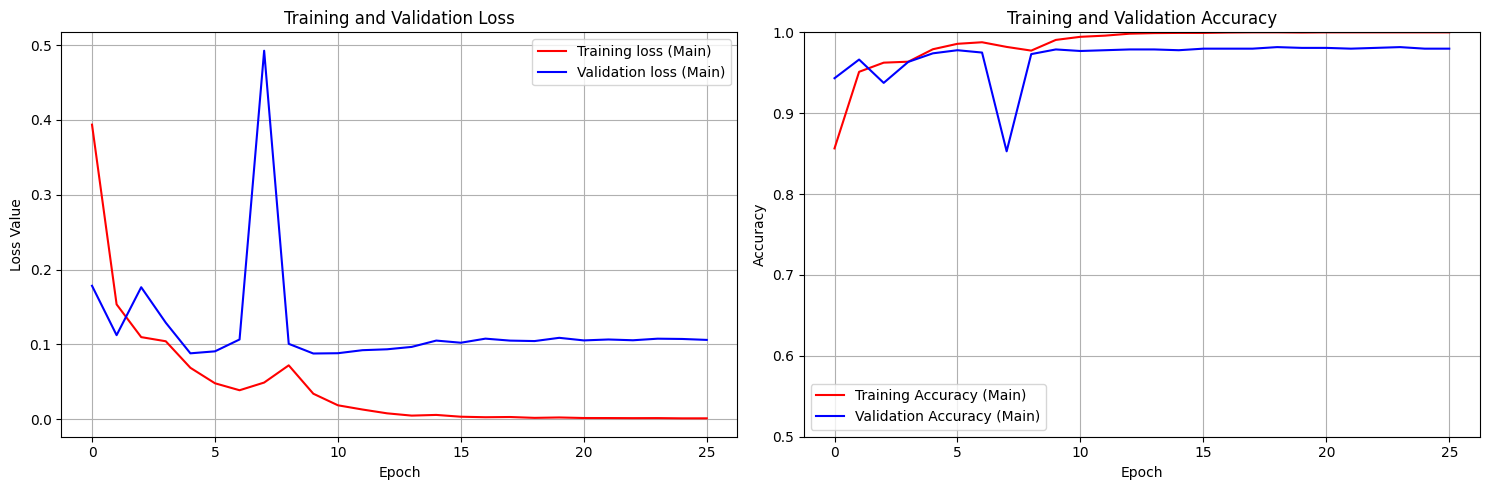

In [68]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
# 파이토치 루프에서 직접 채워넣은 history 딕셔너리를 활용
train_loss = history['loss']
train_accuracy = history['accuracy']
val_loss = history['val_loss']
val_accuracy = history['val_accuracy']

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0]) # 데이터셋 특성에 맞춰 Y축 범위 지정
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

📌 Embedding Space t-SNE
- 모델 구조에 따라 [1. 입력 데이터, 잠재공간 임베딩 벡터 및 라벨 추출] 코드를 수정해주어야 함.

데이터셋으로부터 특징 벡터 및 ResNet 잠재공간 임베딩을 추출하고 있습니다...
▶ 입력 공간 데이터 형태 (Flattened)   : (1040, 240)
▶ 잠재 공간 데이터 형태 (WISDM ResNet) : (1040, 256)

입력 공간(Raw) t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


잠재 공간(ResNet) t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


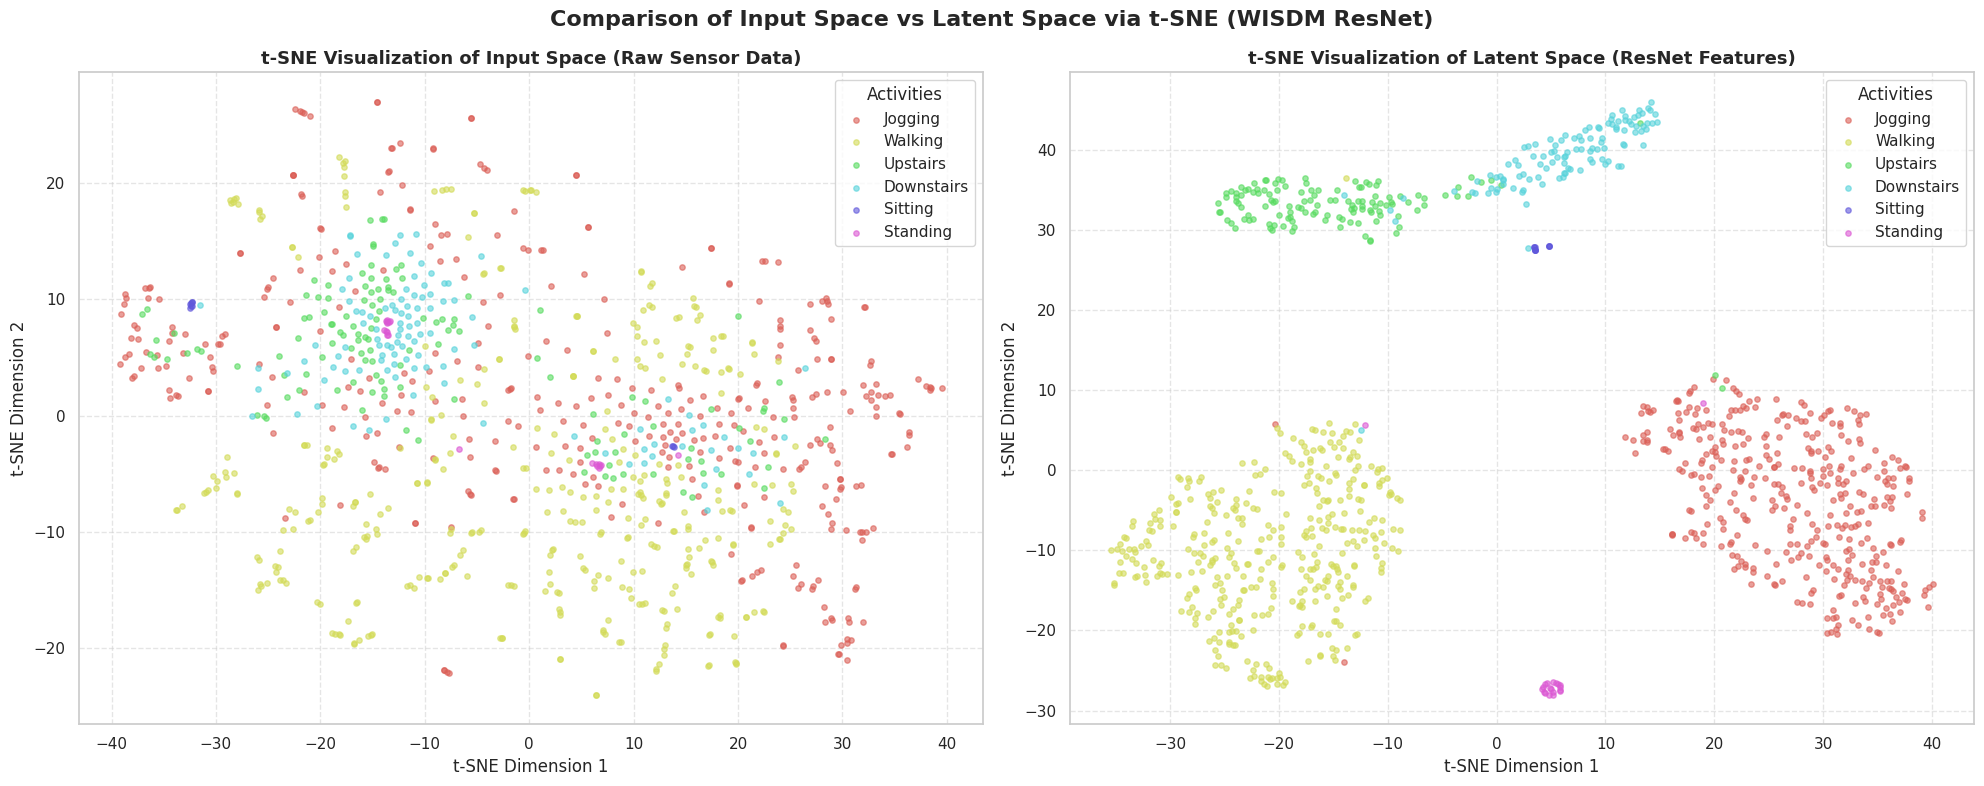

In [71]:
from sklearn.manifold import TSNE

def visualize_dual_tsne_resnet_wisdm(model, data_loader, device):
    model.eval()

    input_features = []
    latent_embeddings = []
    labels = []

    # 1. 입력 데이터, 잠재공간 임베딩 벡터 및 라벨 추출
    print("데이터셋으로부터 특징 벡터 및 ResNet 잠재공간 임베딩을 추출하고 있습니다...")
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            # 1-1. 입력 공간 데이터 수집 (Shape: [Batch, Channel * Length] -> 3 * 80 = 240차원)
            inputs_flatten = batch_X.view(batch_X.size(0), -1).cpu().numpy()
            input_features.append(inputs_flatten)

            # 1-2. 잠재 공간 임베딩 수집 (WISDM ResNet 구조 반영)
            batch_X = batch_X.to(device)
            x = model.prep_block(batch_X) # Stem layer 통과 -> [Batch, 64, 80]
            x = model.layer1(x)           # Residual Stage 1 통과 -> [Batch, 64, 80]
            x = model.layer2(x)           # Residual Stage 2 통과 -> [Batch, 128, 40]
            x = model.layer3(x)           # Residual Stage 3 통과 -> [Batch, 256, 20]

            # [ResNet 구조 반영] AdaptiveAvgPool1d를 통해 시간 축 압축 -> [Batch, 256, 1]
            x = model.adaptive_pool(x)

            # 최종 256차원의 벡터로 Flatten 수행 -> [Batch, 256]
            latent_vector = x.view(x.size(0), -1)
            latent_embeddings.append(latent_vector.cpu().numpy())

            # 1-3. 라벨 처리 (원-핫 인코딩 대응 안전장치)
            if len(batch_y.shape) > 1 and batch_y.shape[1] > 1:
                labels.append(torch.argmax(batch_y, dim=1).cpu().numpy())
            else:
                labels.append(batch_y.cpu().numpy())

    # 리스트에 담긴 배치 데이터를 하나로 결합
    input_features = np.concatenate(input_features, axis=0)
    latent_embeddings = np.concatenate(latent_embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)

    print(f"▶ 입력 공간 데이터 형태 (Flattened)   : {input_features.shape}")
    print(f"▶ 잠재 공간 데이터 형태 (WISDM ResNet) : {latent_embeddings.shape}")

    # 2. t-SNE를 이용한 차원 축소 (각각 2차원으로 축소)
    print("\n입력 공간(Raw) t-SNE 차원 축소 진행 중...")
    tsne_input = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_input_results = tsne_input.fit_transform(input_features)

    print("잠재 공간(ResNet) t-SNE 차원 축소 진행 중...")
    tsne_latent = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_latent_results = tsne_latent.fit_transform(latent_embeddings)

    # 3. Matplotlib 1x2 서브플롯 시각화
    sns.set_theme(style='whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # activity_map에서 순서대로 라벨 텍스트 추출
    class_names = [k for k, v in sorted(activity_map.items(), key=lambda item: item[1])]
    num_classes = len(class_names)

    # 고유한 색상 배정을 위한 컬러 팔레트
    colors = sns.color_palette("hls", num_classes)

    # 두 그래프 모두에 클래스별 데이터 플롯
    for i in range(num_classes):
        indices = np.where(labels == i)

        # [왼쪽] 입력 공간 시각화
        ax1.scatter(
            tsne_input_results[indices, 0],
            tsne_input_results[indices, 1],
            label=class_names[i],
            color=colors[i],
            alpha=0.6,
            s=15
        )

        # [오른쪽] 잠재 공간 시각화
        ax2.scatter(
            tsne_latent_results[indices, 0],
            tsne_latent_results[indices, 1],
            label=class_names[i],
            color=colors[i],
            alpha=0.6,
            s=15
        )

    # 왼쪽 Plot(입력 공간) 스타일링
    ax1.set_title('t-SNE Visualization of Input Space (Raw Sensor Data)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='best', title="Activities")

    # 오른쪽 Plot(잠재 공간) 스타일링
    ax2.set_title('t-SNE Visualization of Latent Space (ResNet Features)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('t-SNE Dimension 1')
    ax2.set_ylabel('t-SNE Dimension 2')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='best', title="Activities")

    plt.suptitle('Comparison of Input Space vs Latent Space via t-SNE (WISDM ResNet)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# --- 시각화 함수 호출 ---
visualize_dual_tsne_resnet_wisdm(best_model, val_loader, device)

📌 혼동 행렬 (Confusion Matrix)

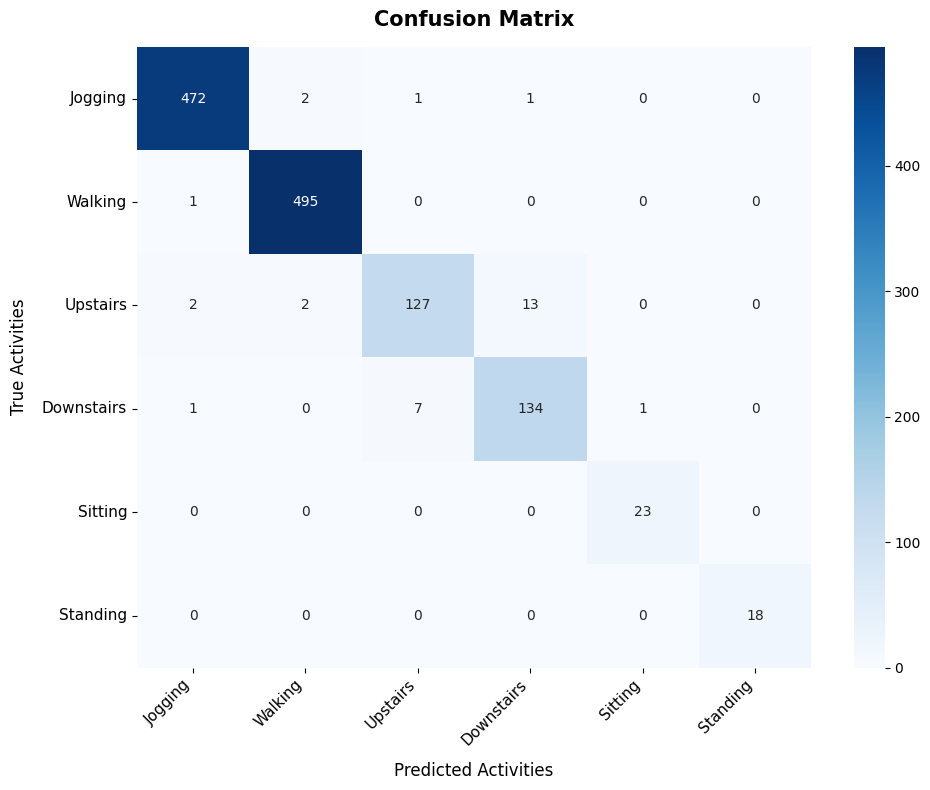

In [70]:
# --- 1. 혼동 행렬(Confusion Matrix) 계산 ---
cm = confusion_matrix(y_test, y_pred)

# --- 2. Seaborn Heatmap을 이용한 시각화 ---
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# --- 3. 축 레이블 및 타이틀 설정 (WISDM 스펙 최적화) ---
# 전처리 시 생성했던 activity_map에서 인덱스 순서대로 정확한 액티비티 명칭 추출
class_names = [k for k, v in sorted(activity_map.items(), key=lambda item: item[1])]

plt.title('Confusion Matrix', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Activities', fontsize=12, labelpad=10)
plt.ylabel('True Activities', fontsize=12, labelpad=10)

# 추출한 클래스명으로 X축, Y축 레이블 동적 매핑
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right', fontsize=11)
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()